In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

I0000 00:00:1789087066.020292  626225 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17114__.17
I0000 00:00:1789087067.811963  626227 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17114__.17


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0126


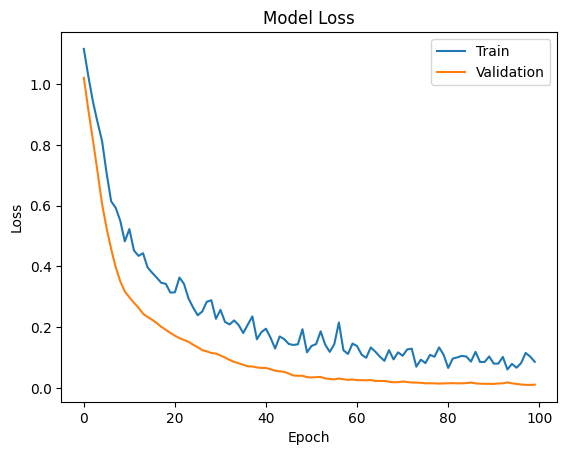

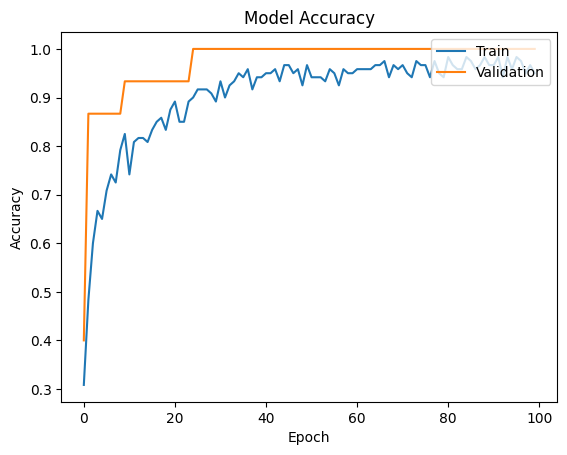

In [6]:
iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

model = Sequential([
    Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dropout(0.2),
    Dense(16, activation = 'relu'),
    Dropout(0.2),
    Dense(3, activation = 'softmax')])

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
hist = model.fit(X_train, y_train, validation_data = (X_valid, y_valid), epochs = 100, batch_size = 16, verbose = 0)
model.evaluate(X_test, y_test)

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()


plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc = 'upper right')
plt.show()